In [117]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score, cross_val_predict
from sklearn.linear_model import PoissonRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (mean_absolute_error, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


DATA_DIR = Path('.')

def load_csv(filename, **kwargs):
    path = DATA_DIR / filename
    df = pd.read_csv(path, **kwargs)
    print(f'Loaded {filename}: {df.shape[0]} rows, {df.shape[1]} columns')
    return df

In [118]:
# Import CSVs
results = load_csv('results.csv')
group_fixtures = load_csv('group_fixtures.csv')
knockout_slots = load_csv('knockout_slots.csv')
fifa_1 = load_csv('fifa_ranking-2023-07-20.csv')
fifa_2 = load_csv('fifa_ranking-2024-04-04.csv')
fifa_3 = load_csv('fifa_ranking-2024-06-20.csv')

# Add together
fifa_rankings = pd.concat([fifa_1, fifa_2, fifa_3], ignore_index=True)

Loaded results.csv: 49411 rows, 9 columns
Loaded group_fixtures.csv: 72 rows, 6 columns
Loaded knockout_slots.csv: 32 rows, 7 columns
Loaded fifa_ranking-2023-07-20.csv: 64757 rows, 8 columns
Loaded fifa_ranking-2024-04-04.csv: 67261 rows, 8 columns
Loaded fifa_ranking-2024-06-20.csv: 67472 rows, 8 columns


In [119]:
# Parse dates
results['date'] = pd.to_datetime(results['date'], errors='coerce')
group_fixtures['date_utc'] = pd.to_datetime(group_fixtures['date_utc'], errors='coerce')
fifa_rankings['country_full'] = fifa_rankings['country_full'].replace(manual_team_map)
fifa_rankings['rank_date'] = pd.to_datetime(fifa_rankings['rank_date'], errors='coerce')


In [120]:
# Name mapping (ex. United States -> USA, etc.)
manual_team_map = {
    "USA": "United States",
    "Côte d'Ivoire" : "Ivory Coast",
    "Cabo Verde" : "Cape Verde",
    "UEFA Playoff A": "Bosnia and Herzegovina",
    "UEFA Playoff B": "Sweden",
    "UEFA Playoff C": "Turkey",
    "UEFA Playoff D": "Czech Republic",
    "FIFA Playoff 1": "DR Congo",
    "FIFA Playoff 2": "Iraq",
}
group_fixtures['home_team'] = group_fixtures['home_team'].replace(manual_team_map)
group_fixtures['away_team'] = group_fixtures['away_team'].replace(manual_team_map)

print('group_fixtures teams after mapping:')
all_teams = sorted(set(group_fixtures['home_team']) | set(group_fixtures['away_team']))
for t in all_teams:
    n = len(results[(results['home_team']==t)|(results['away_team']==t)])
    flag = '  ⚠️  not found in results.csv' if n == 0 else ''
    print(f'  {t:<35}  {n:>5} historical matches{flag}')


group_fixtures teams after mapping:
  Algeria                                619 historical matches
  Argentina                             1070 historical matches
  Australia                              583 historical matches
  Austria                                863 historical matches
  Belgium                                855 historical matches
  Bosnia and Herzegovina                 285 historical matches
  Brazil                                1061 historical matches
  Canada                                 472 historical matches
  Cape Verde                             237 historical matches
  Colombia                               640 historical matches
  Croatia                                398 historical matches
  Curaçao                                387 historical matches
  Czech Republic                         363 historical matches
  DR Congo                               526 historical matches
  Ecuador                                593 historical matches
  Eg

In [121]:
# Build historical database for training
fifa_rankings = fifa_rankings.sort_values(['country_full', 'rank_date'])
results = results.sort_values('date')

home_rankings = fifa_rankings.rename(columns={
    'country_full': 'home_team',
    'rank': 'home_rank',
    'total_points': 'home_points',
    'previous_points': 'home_previous_points',
    'rank_date': 'home_rank_date'
})
home_rankings = home_rankings.sort_values('home_rank_date')  # Sort ONLY by rank date

away_rankings = fifa_rankings.rename(columns={
    'country_full': 'away_team',
    'rank': 'away_rank',
    'total_points': 'away_points',
    'previous_points': 'away_previous_points',
    'rank_date': 'away_rank_date'
})
away_rankings = away_rankings.sort_values('away_rank_date')  # Sort ONLY by rank date

# Merge home and away fifa rankings into results dataset
results = pd.merge_asof(
    results,
    home_rankings,
    left_on='date',
    right_on='home_rank_date',
    left_by='home_team',
    right_by='home_team',
    direction='backward'
)

results = pd.merge_asof(
    results,
    away_rankings,
    left_on='date',
    right_on='away_rank_date',
    left_by='away_team',
    right_by='away_team',
    direction='backward'
)

print(f'results shape after ranking merge: {results.shape}')
print(f'NaN in home_rank : {results["home_rank"].isna().sum():,}')
print(f'NaN in away_rank : {results["away_rank"].isna().sum():,}')
print()
print('📘 NaN ranks = teams not in the FIFA ranking file.')
print('   These rows will be dropped in the next cell.')

results shape after ranking merge: (49411, 23)
NaN in home_rank : 21,504
NaN in away_rank : 21,726

📘 NaN ranks = teams not in the FIFA ranking file.
   These rows will be dropped in the next cell.


In [122]:
# # Filter to only the competitive teams
# results = results.drop(index=results[results['tournament'] == 'Friendly'].index)

# # Get rid of any invalid scores
# results = results.dropna()

# # Drop anything earlier than 2010 games
# cutoff_date = pd.to_datetime('2010-01-01')

# pre_2010_excluded = results[results['date'] <= cutoff_date].index
# results = results.drop(index=pre_2010_excluded)

COMPETITIVE_TOURNAMENTS = {
    'FIFA World Cup',              'FIFA World Cup qualification',
    'UEFA Euro',                   'UEFA Euro qualification',
    'Copa América',                'Copa América qualification',
    'AFC Asian Cup',               'AFC Asian Cup qualification',
    'African Cup of Nations',      'African Cup of Nations qualification',
    'Gold Cup',                    'Gold Cup qualification',
    'UEFA Nations League',         'CONCACAF Nations League',
    'Confederations Cup',
}

before = len(results)

# FIX #3: keep only the 15 named competitive types (not just ≠ Friendly)
results = results[results['tournament'].isin(COMPETITIVE_TOURNAMENTS)].copy()
print(f'After competitive filter : {len(results):>7,}  (dropped {before-len(results):,})')

# FIX #4: drop only rows missing the columns we need
results = results.dropna(subset=['home_score','away_score','home_rank','away_rank'])
print(f'After targeted dropna    : {len(results):>7,}')

# 2010+ cutoff
results = results[results['date'] > '2010-01-01'].copy()
print(f'After 2010+ cutoff       : {len(results):>7,}')

results = results.reset_index(drop=True)
results['match_id'] = results.index

print()
print('Rows by tournament:')
print(results['tournament'].value_counts().to_string())


After competitive filter :  20,046  (dropped 29,365)
After targeted dropna    :  13,470
After 2010+ cutoff       :   7,474

Rows by tournament:
tournament
FIFA World Cup qualification            3081
UEFA Euro qualification                 1006
African Cup of Nations qualification     988
UEFA Nations League                      658
African Cup of Nations                   337
CONCACAF Nations League                  246
FIFA World Cup                           230
AFC Asian Cup qualification              225
Gold Cup                                 189
UEFA Euro                                184
Copa América                             170
AFC Asian Cup                            110
Confederations Cup                        32
Gold Cup qualification                    14
Copa América qualification                 4


In [123]:
# Unpivot for per-team statistics
# Home team rows
home = results[['match_id', 'date', 'home_team', 'away_team', 'home_score', 'away_score', 'home_rank', 'away_rank', 'home_points', 'away_points']].copy()
home = home.rename(columns={
    'home_team': 'team',
    'away_team': 'opponent',
    'home_score': 'goals_for',  
    'away_score': 'goals_against', 
    'home_rank': 'team_rank',
    'away_rank': 'opp_rank',
    'home_points': 'team_points',
    'away_points': 'opp_points'
})
home['is_home'] = 1

# Away team rows
away = results[['match_id', 'date', 'home_team', 'away_team', 'home_score', 'away_score', 'home_rank', 'away_rank', 'home_points', 'away_points']].copy()
away = away.rename(columns={
    'away_team': 'team',
    'home_team': 'opponent',
    'away_score': 'goals_for',
    'home_score': 'goals_against',
    'away_rank': 'team_rank',
    'home_rank': 'opp_rank',
    'away_points': 'team_points',
    'home_points': 'opp_points'
})
away['is_home'] = 0

# Stack them
team_matches = pd.concat([home, away], ignore_index=True)
team_matches = team_matches.sort_values(['team', 'date', 'match_id']).reset_index(drop=True)

print(f'team_matches: {team_matches.shape}  ({len(results):,} matches × 2 sides)')
print()
print('Verify — match_id 0 appears exactly twice:')
display(team_matches[team_matches['match_id']==0][
    ['match_id','team','opponent','goals_for','goals_against','is_home']
])

team_matches: (14948, 11)  (7,474 matches × 2 sides)

Verify — match_id 0 appears exactly twice:


,match_id,team,opponent,goals_for,goals_against,is_home
1092,0,Bahrain,Hong Kong,4.0,0.0,1
6271,0,Hong Kong,Bahrain,0.0,4.0,0


In [124]:
# ── Outcome flags ─────────────────────────────────────────────────────────────
team_matches['goal_diff'] = team_matches['goals_for'] - team_matches['goals_against']
team_matches['win']       = (team_matches['goal_diff'] > 0).astype(int)
team_matches['draw']      = (team_matches['goal_diff'] == 0).astype(int)
team_matches['loss']      = (team_matches['goal_diff'] < 0).astype(int)
team_matches['points']    = team_matches['win'] * 3 + team_matches['draw']

# ── Leave-one-out cumulative stats ────────────────────────────────────────────
team_matches['n'] = team_matches.groupby('team').cumcount()   # 0, 1, 2, ...

for col in ['goals_for','goals_against','goal_diff','points','win','draw','loss']:
    team_matches[f'cum_{col}'] = (
        team_matches.groupby('team')[col]
        .transform(lambda x: x.cumsum().shift(1).fillna(0))
    )

# ── Per-game averages (NaN when n=0 — no prior history yet) ──────────────────
n = team_matches['n'].replace(0, np.nan)
team_matches['avg_gf_prior']     = (team_matches['cum_goals_for']        / n).round(4)
team_matches['avg_ga_prior']     = (team_matches['cum_goals_against']        / n).round(4)
team_matches['avg_gd_prior']     = (team_matches['cum_goal_diff'] / n).round(4)
team_matches['avg_points_prior'] = (team_matches['cum_points']    / n).round(4)
team_matches['win_pct_prior']    = (team_matches['cum_win']       / n).round(4)
team_matches['draw_pct_prior']   = (team_matches['cum_draw']      / n).round(4)
team_matches['loss_pct_prior']   = (team_matches['cum_loss']      / n).round(4)

print('team_matches sample (France, first 6 rows):')
display(team_matches[team_matches['team']=='France'][[
    'date','opponent','goals_for','goals_against','n',
    'avg_gf_prior','avg_ga_prior','avg_points_prior','win_pct_prior'
]].head(6))


team_matches sample (France, first 6 rows):


,date,opponent,goals_for,goals_against,n,avg_gf_prior,avg_ga_prior,avg_points_prior,win_pct_prior
4947,2010-06-11,Uruguay,0.0,0.0,0,NaN,NaN,NaN,NaN
4948,2010-06-17,Mexico,0.0,2.0,1,0.0000,0.0000,1.0000,0.0
4949,2010-06-22,South Africa,1.0,2.0,2,0.0000,1.0000,0.5000,0.0
4950,2010-09-03,Belarus,0.0,1.0,3,0.3333,1.3333,0.3333,0.0
4951,2010-09-07,Bosnia and Herzegovina,2.0,0.0,4,0.2500,1.2500,0.2500,0.0
4952,2010-10-09,Romania,2.0,0.0,5,0.6000,1.0000,0.8000,0.2


In [125]:
# Pivot Form Features Back onto Match Rows

FORM_COLS = ['n','avg_gf_prior','avg_ga_prior','avg_gd_prior',
             'avg_points_prior','win_pct_prior','draw_pct_prior','loss_pct_prior']

# Home-side features
home_feats = team_matches[team_matches['is_home']==1][['match_id'] + FORM_COLS].copy()
home_feats.columns = ['match_id'] + ['home_' + c for c in FORM_COLS]

# Away-side features  (FIX #7: this was the cut-off line)
away_feats = team_matches[team_matches['is_home']==0][['match_id'] + FORM_COLS].copy()
away_feats.columns = ['match_id'] + ['away_' + c for c in FORM_COLS]

# Join both back onto the match-level table
match_features = results[[
    'match_id','date','home_team','away_team',
    'home_score','away_score',
    'home_rank','away_rank','home_points','away_points',
    'tournament','neutral'
]].copy()

match_features = match_features.merge(home_feats, on='match_id', how='left')
match_features = match_features.merge(away_feats, on='match_id', how='left')

match_features['rank_diff']   = match_features['home_rank']  - match_features['away_rank']
match_features['points_diff'] = match_features['home_points'] - match_features['away_points']

# Target variables
match_features['home_goals'] = match_features['home_score'].astype(float)
match_features['away_goals'] = match_features['away_score'].astype(float)
match_features['goal_diff']  = match_features['home_goals'] - match_features['away_goals']
match_features['result']     = match_features['goal_diff'].apply(
    lambda x: 'home_win' if x > 0 else ('away_win' if x < 0 else 'draw'))

print(f'match_features shape: {match_features.shape}')
bad = [c for c in match_features.columns if '_x' in c or '_y' in c]
print(f'Duplicate _x/_y columns: {bad if bad else "None ✅"}')
print()
print('Sample:')
display(match_features[['date','home_team','away_team',
                          'home_rank','away_rank','rank_diff',
                          'home_avg_gf_prior','away_avg_gf_prior',
                          'home_goals','away_goals','result']].head(4))


match_features shape: (7474, 34)
Duplicate _x/_y columns: None ✅

Sample:


,date,home_team,away_team,home_rank,away_rank,rank_diff,home_avg_gf_prior,away_avg_gf_prior,home_goals,away_goals,result
0,2010-01-06,Bahrain,Hong Kong,60.0,143.0,-83.0,NaN,NaN,4.0,0.0,home_win
1,2010-01-06,China PR,Syria,93.0,91.0,2.0,NaN,NaN,0.0,0.0,draw
2,2010-01-06,Indonesia,Oman,120.0,79.0,41.0,NaN,NaN,1.0,2.0,away_win
3,2010-01-06,Kuwait,Australia,104.0,21.0,83.0,NaN,NaN,2.0,2.0,draw


In [126]:
# Final Training Matrix

FEATURE_COLS = [
    'home_rank',         'away_rank',          'rank_diff',
    'home_avg_gf_prior', 'away_avg_gf_prior',
    'home_avg_ga_prior', 'away_avg_ga_prior',
    'home_avg_gd_prior', 'away_avg_gd_prior',
    'home_avg_points_prior', 'away_avg_points_prior',
    'home_win_pct_prior','away_win_pct_prior',
]

df_model = match_features[
    FEATURE_COLS + ['home_goals','away_goals','goal_diff','result']
].dropna().copy()

X = df_model[FEATURE_COLS].values
y_home   = df_model['home_goals'].values      # for Poisson / regression
y_away   = df_model['away_goals'].values
y_result = df_model['result'].values          # for RFC classification

print(f'Training matrix  : {X.shape[0]:,} rows × {X.shape[1]} features')
print(f'Rows dropped (no prior history) : {len(match_features) - len(df_model):,}')
print()
print('Target distributions:')
print(f'  home_goals  mean={y_home.mean():.3f}  var={y_home.var():.3f}')
print(f'  away_goals  mean={y_away.mean():.3f}  var={y_away.var():.3f}')
vc = pd.Series(y_result).value_counts()
for cls, cnt in vc.items():
    print(f'  {cls:<12}  {cnt:,}  ({cnt/len(y_result):.1%})')
print()
print('📘 Poisson check — mean should be close to variance for a good fit:')
for name, arr in [('home_goals', y_home), ('away_goals', y_away)]:
    ratio = arr.var() / arr.mean()
    note = 'slight overdispersion (still usable)' if ratio > 1.2 else 'good fit'
    print(f'  {name}  mean={arr.mean():.3f}  var={arr.var():.3f}  ratio={ratio:.3f}  → {note}')


Training matrix  : 7,336 rows × 13 features
Rows dropped (no prior history) : 138

Target distributions:
  home_goals  mean=1.569  var=2.514
  away_goals  mean=1.106  var=1.627
  home_win      3,473  (47.3%)
  away_win      2,213  (30.2%)
  draw          1,650  (22.5%)

📘 Poisson check — mean should be close to variance for a good fit:
  home_goals  mean=1.569  var=2.514  ratio=1.602  → slight overdispersion (still usable)
  away_goals  mean=1.106  var=1.627  ratio=1.471  → slight overdispersion (still usable)


In [127]:
# Poisson Regression (Predict Goals)
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

poisson_home = Pipeline([('scaler', StandardScaler()),
                          ('model',  PoissonRegressor(max_iter=500))])
poisson_away = Pipeline([('scaler', StandardScaler()),
                          ('model',  PoissonRegressor(max_iter=500))])

# 5-fold cross-validation
h_scores = cross_val_score(poisson_home, X, y_home, cv=kfold,
                            scoring='neg_mean_absolute_error')
a_scores = cross_val_score(poisson_away, X, y_away, cv=kfold,
                            scoring='neg_mean_absolute_error')

print('=' * 46)
print('  Poisson Regression — 5-fold CV Results')
print('=' * 46)
print(f'  Home goals  MAE : {-h_scores.mean():.4f}  ± {h_scores.std():.4f}')
print(f'  Away goals  MAE : {-a_scores.mean():.4f}  ± {a_scores.std():.4f}')
print()
print('📘 MAE interpretation:')
print('   An MAE of ~1.0 means predictions are off by about 1 goal on average.')
print('   This is typical for football — the sport is inherently low-scoring')
print('   and high-variance. MAE below 0.95 is considered good.')
print()

# Train on full dataset for prediction use
poisson_home.fit(X, y_home)
poisson_away.fit(X, y_away)
print('✅  Poisson models trained on full dataset.')


  Poisson Regression — 5-fold CV Results
  Home goals  MAE : 1.0088  ± 0.0264
  Away goals  MAE : 0.8361  ± 0.0147

📘 MAE interpretation:
   An MAE of ~1.0 means predictions are off by about 1 goal on average.
   This is typical for football — the sport is inherently low-scoring
   and high-variance. MAE below 0.95 is considered good.

✅  Poisson models trained on full dataset.


/Users/zara/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/zara/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/zara/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/zara/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/zara/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_streng

In [128]:
# Random Forest Classifier to Predict Match Outcome
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

CLASS_ORDER = ['home_win', 'draw', 'away_win']
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfc = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators    = 500,
        max_depth       = 8,
        min_samples_leaf= 20,
        class_weight    = 'balanced',   # corrects for fewer draws in the data
        random_state    = 42,
        n_jobs          = -1,
    ))
])

# Cross-validated accuracy and F1
cv_acc = cross_val_score(rfc, X, y_result, cv=skfold, scoring='accuracy')
cv_f1  = cross_val_score(rfc, X, y_result, cv=skfold, scoring='f1_macro')

print('=' * 52)
print('  Random Forest Classifier — 5-fold CV Results')
print('=' * 52)
print(f'  Accuracy  : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}')
print(f'  F1-macro  : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}')
print(f'  Baseline (always predict home_win): {(y_result=="home_win").mean():.4f}')
print()
print('📘 F1-macro averages F1 across all 3 classes equally.')
print('   It is more informative than accuracy when classes are imbalanced.')

# Train on full dataset
rfc.fit(X, y_result)
print()
print('✅  RFC trained on full dataset.')


  Random Forest Classifier — 5-fold CV Results
  Accuracy  : 0.5639  ± 0.0127
  F1-macro  : 0.5220  ± 0.0103
  Baseline (always predict home_win): 0.4734

📘 F1-macro averages F1 across all 3 classes equally.
   It is more informative than accuracy when classes are imbalanced.

✅  RFC trained on full dataset.


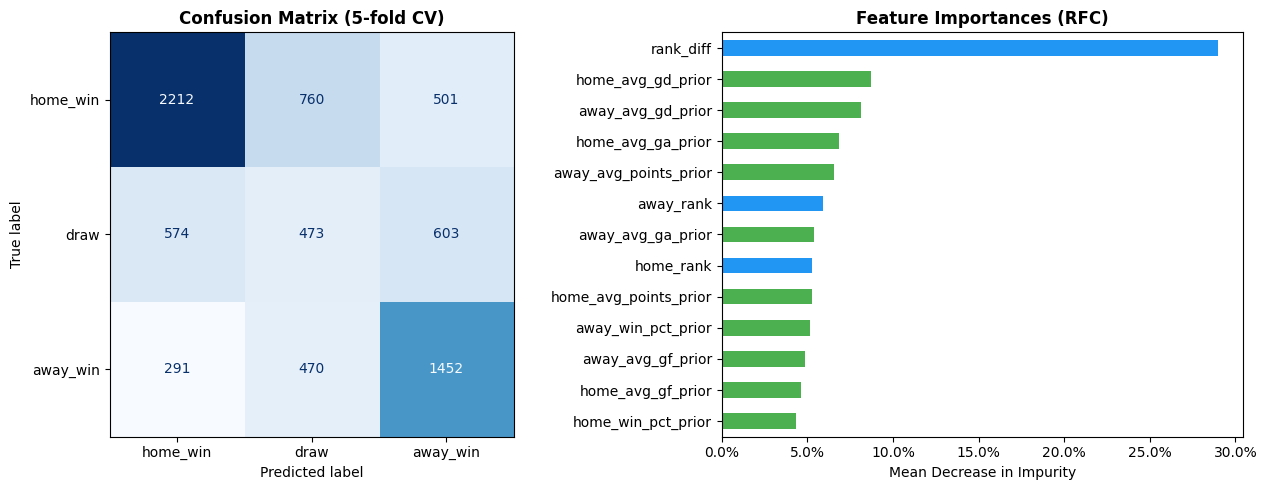


Classification report (out-of-fold):
              precision    recall  f1-score   support

    home_win       0.57      0.66      0.61      2213
        draw       0.28      0.29      0.28      1650
    away_win       0.72      0.64      0.68      3473

    accuracy                           0.56      7336
   macro avg       0.52      0.53      0.52      7336
weighted avg       0.57      0.56      0.57      7336


Top 5 most important features:
  rank_diff                       0.2898
  home_avg_gd_prior               0.0870
  away_avg_gd_prior               0.0814
  home_avg_ga_prior               0.0685
  away_avg_points_prior           0.0654


In [129]:
# ── Confusion matrix (out-of-fold predictions — no leakage) ──────────────────
y_cv_pred = cross_val_predict(rfc, X, y_result, cv=skfold)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_result, y_cv_pred, labels=CLASS_ORDER)
ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (5-fold CV)', fontweight='bold')

# Right: feature importances
fitted_rfc = rfc.named_steps['clf']
imp = pd.Series(fitted_rfc.feature_importances_, index=FEATURE_COLS).sort_values()
colors = ['#2196F3' if 'rank' in c else '#4CAF50' for c in imp.index]
imp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Feature Importances (RFC)', fontweight='bold')
axes[1].set_xlabel('Mean Decrease in Impurity')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))

plt.tight_layout()
plt.show()

print()
print('Classification report (out-of-fold):')
print(classification_report(y_result, y_cv_pred, target_names=CLASS_ORDER))

print()
print('Top 5 most important features:')
for feat, val in imp.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<30}  {val:.4f}')


In [130]:
# ── Latest form per team ──────────────────────────────────────────────────────
latest_form = (
    team_matches.sort_values('date')
    .groupby('team')
    .last()
    .reset_index()
    [['team','avg_gf_prior','avg_ga_prior','avg_gd_prior',
      'avg_points_prior','win_pct_prior','draw_pct_prior','loss_pct_prior']]
)

# ── Latest FIFA ranking per team ──────────────────────────────────────────────
latest_rank = (
    fifa_rankings.sort_values('rank_date')
    .groupby('country_full')
    .last()
    .reset_index()
    [['country_full','rank','total_points']]
    .rename(columns={'country_full':'team','rank':'fifa_rank','total_points':'fifa_points'})
)

# ── Build feature row for each fixture ────────────────────────────────────────
def get_team_features(fixture_name):
    """Return form + ranking features for one team, keyed by fixture name."""
    results_nm = manual_team_map.get(fixture_name, fixture_name)

    form = latest_form[latest_form['team'] == results_nm]
    rank = latest_rank[latest_rank['team'] == results_nm]

    form_vals = form.iloc[0].to_dict() if len(form) else {
        'avg_gf_prior':1.0,'avg_ga_prior':1.0,'avg_gd_prior':0.0,
        'avg_points_prior':1.0,'win_pct_prior':0.33,
        'draw_pct_prior':0.22,'loss_pct_prior':0.45}

    rank_val = float(rank.iloc[0]['fifa_rank'])   if len(rank) else 150.0
    pts_val  = float(rank.iloc[0]['fifa_points']) if len(rank) else 0.0

    return {**form_vals, 'fifa_rank': rank_val, 'fifa_points': pts_val}

rows = []
for _, fixture in group_fixtures.iterrows():
    h, a = fixture['home_team'], fixture['away_team']
    hf = get_team_features(h)
    af = get_team_features(a)
    rows.append({
        'match_id'    : fixture['match_id'],
        'group'       : fixture['group'],
        'date_utc'    : fixture['date_utc'],
        'home_team'   : h,
        'away_team'   : a,
        'home_rank'          : hf['fifa_rank'],
        'away_rank'          : af['fifa_rank'],
        'rank_diff'          : hf['fifa_rank']          - af['fifa_rank'],
        'home_avg_gf_prior'  : hf['avg_gf_prior'],
        'away_avg_gf_prior'  : af['avg_gf_prior'],
        'home_avg_ga_prior'  : hf['avg_ga_prior'],
        'away_avg_ga_prior'  : af['avg_ga_prior'],
        'home_avg_gd_prior'  : hf['avg_gd_prior'],
        'away_avg_gd_prior'  : af['avg_gd_prior'],
        'home_avg_points_prior': hf['avg_points_prior'],
        'away_avg_points_prior': af['avg_points_prior'],
        'home_win_pct_prior' : hf['win_pct_prior'],
        'away_win_pct_prior' : af['win_pct_prior'],
    })

pred_df = pd.DataFrame(rows)

# ── Predict ───────────────────────────────────────────────────────────────────
X_pred = pred_df[FEATURE_COLS].fillna(pred_df[FEATURE_COLS].median())

# Poisson: expected goals
pred_df['exp_home_goals'] = poisson_home.predict(X_pred.values).clip(0).round(3)
pred_df['exp_away_goals'] = poisson_away.predict(X_pred.values).clip(0).round(3)
pred_df['pred_home_goals'] = pred_df['exp_home_goals'].round().astype(int)
pred_df['pred_away_goals'] = pred_df['exp_away_goals'].round().astype(int)

# RFC: outcome probabilities
proba  = rfc.predict_proba(X_pred.values)
proba_classes = list(rfc.classes_)
for cls in CLASS_ORDER:
    pred_df[f'prob_{cls}'] = proba[:, proba_classes.index(cls)].round(3)
pred_df['pred_result'] = rfc.predict(X_pred.values)

print('Group stage predictions:')
display(pred_df[['group','home_team','away_team',
                  'pred_home_goals','pred_away_goals',
                  'pred_result','prob_home_win','prob_draw','prob_away_win']])


Group stage predictions:


,group,home_team,away_team,pred_home_goals,pred_away_goals,pred_result,prob_home_win,prob_draw,prob_away_win
0,A,Mexico,South Africa,2,1,home_win,0.468,0.390,0.141
1,A,South Korea,Czech Republic,1,2,away_win,0.129,0.359,0.512
2,B,Canada,Bosnia and Herzegovina,2,1,home_win,0.441,0.395,0.164
3,D,United States,Paraguay,2,1,home_win,0.654,0.257,0.089
4,D,Australia,Turkey,2,1,home_win,0.419,0.416,0.165
...,...,...,...,...,...,...,...,...,...
67,L,Croatia,Ghana,2,1,home_win,0.483,0.349,0.168
68,K,Colombia,Portugal,1,1,draw,0.186,0.437,0.377
69,K,DR Congo,Uzbekistan,1,2,away_win,0.107,0.383,0.510
70,J,Algeria,Austria,1,1,away_win,0.267,0.343,0.390


In [131]:
# Group Standings
def simulate_standings(group_label, pred_df):
    gm = pred_df[pred_df['group'] == group_label].copy()
    teams = sorted(set(gm['home_team']) | set(gm['away_team']))
    rec = {t: dict(team=t, group=group_label, P=0, W=0, D=0, L=0, GF=0, GA=0) for t in teams}

    for _, r in gm.iterrows():
        h, a   = r['home_team'], r['away_team']
        hg, ag = int(r['pred_home_goals']), int(r['pred_away_goals'])
        rec[h]['P']  += 1;  rec[a]['P']  += 1
        rec[h]['GF'] += hg; rec[h]['GA'] += ag
        rec[a]['GF'] += ag; rec[a]['GA'] += hg
        if hg > ag:   rec[h]['W'] += 1; rec[a]['L'] += 1
        elif ag > hg: rec[a]['W'] += 1; rec[h]['L'] += 1
        else:         rec[h]['D'] += 1; rec[a]['D'] += 1

    st = pd.DataFrame(list(rec.values()))
    st['GD']  = st['GF'] - st['GA']
    st['Pts'] = st['W'] * 3 + st['D']
    st = st.sort_values(['Pts','GD','GF'], ascending=False).reset_index(drop=True)
    st.index += 1
    st['qualify'] = st.index.map(lambda i: '✅' if i <= 2 else '')
    return st[['team','group','P','W','D','L','GF','GA','GD','Pts','qualify']]

all_standings = []
for grp in sorted(pred_df['group'].dropna().unique()):
    s = simulate_standings(grp, pred_df)
    all_standings.append(s)
    print(f'Group {grp}:')
    display(s)
    print()

full_standings = pd.concat(all_standings).reset_index(drop=True)


Group A:


,team,group,P,W,D,L,GF,GA,GD,Pts,qualify
1,Mexico,A,3,2,1,0,6,3,3,7,✅
2,Czech Republic,A,3,1,2,0,4,3,1,5,✅
3,South Africa,A,3,1,1,1,4,4,0,4,
4,South Korea,A,3,0,0,3,3,7,-4,0,



Group B:


,team,group,P,W,D,L,GF,GA,GD,Pts,qualify
1,Switzerland,B,3,2,1,0,5,3,2,7,✅
2,Canada,B,3,1,1,1,4,4,0,4,✅
3,Qatar,B,3,0,3,0,3,3,0,3,
4,Bosnia and Herzegovina,B,3,0,1,2,3,5,-2,1,



Group C:


...

,team,group,P,W,D,L,GF,GA,GD,Pts,qualify
1,Argentina,J,3,2,1,0,5,3,2,7,✅
2,Austria,J,3,1,1,1,4,4,0,4,✅
3,Algeria,J,3,0,2,1,3,4,-1,2,
4,Jordan,J,3,0,2,1,3,4,-1,2,



Group K:


,team,group,P,W,D,L,GF,GA,GD,Pts,qualify
1,Portugal,K,3,2,1,0,6,2,4,7,✅
2,Colombia,K,3,1,2,0,4,3,1,5,✅
3,Uzbekistan,K,3,1,1,1,4,4,0,4,
4,DR Congo,K,3,0,0,3,2,7,-5,0,



Group L:


,team,group,P,W,D,L,GF,GA,GD,Pts,qualify
1,England,L,3,2,1,0,5,3,2,7,✅
2,Croatia,L,3,1,1,1,4,4,0,4,✅
3,Panama,L,3,0,3,0,3,3,0,3,
4,Ghana,L,3,0,1,2,3,5,-2,1,


In [132]:
# Export Results
pred_df[[
    'match_id','group','date_utc','home_team','away_team',
    'pred_home_goals','pred_away_goals',
    'exp_home_goals','exp_away_goals',
    'pred_result','prob_home_win','prob_draw','prob_away_win'
]].to_csv('group_predictions.csv', index=False)
print('✅  Saved: group_predictions.csv')

full_standings.to_csv('group_standings.csv', index=False)
print('✅  Saved: group_standings.csv')

display(pred_df[['group','home_team','away_team',
                  'pred_home_goals','pred_away_goals',
                  'prob_home_win','prob_draw','prob_away_win']].head(12))


✅  Saved: group_predictions.csv
✅  Saved: group_standings.csv


,group,home_team,away_team,pred_home_goals,pred_away_goals,prob_home_win,prob_draw,prob_away_win
0,A,Mexico,South Africa,2,1,0.468,0.390,0.141
1,A,South Korea,Czech Republic,1,2,0.129,0.359,0.512
2,B,Canada,Bosnia and Herzegovina,2,1,0.441,0.395,0.164
3,D,United States,Paraguay,2,1,0.654,0.257,0.089
4,D,Australia,Turkey,2,1,0.419,0.416,0.165
5,B,Qatar,Switzerland,1,1,0.247,0.350,0.404
6,C,Brazil,Morocco,1,1,0.361,0.426,0.213
7,C,Haiti,Scotland,1,1,0.203,0.413,0.384
8,E,Germany,Curaçao,2,1,0.690,0.225,0.085
9,F,Netherlands,Japan,2,1,0.326,0.426,0.247
